# [[5,1,3]] Code Data Generation - New Qubit Layout

Clean implementation with unified qubit mapping.

**Key Changes from Base:**
- Shared ancilla qubits (4 total, not 4 per node)
- Unified `CODE_LAYOUT` dictionary structure
- Reduced total qubits: 49 vs 69

**Protocol:**
1. Encode logical qubit at source using [[5,1,3]] code
2. SWAP encoded state along multi-hop path to sink
3. Measure syndrome at sink using shared ancillas

In [1]:
import sys
sys.path.insert(0, '../..')  # Add project root to path

from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.visualization import plot_histogram

import numpy as np
import networkx as nx
import pickle
import os
from itertools import combinations
from typing import Dict, List, Tuple

## New Qubit Layout

**Structure:**
```
CODE_LAYOUT = {
    'ancillas': [0, 1, 2, 3],           # 4 shared ancilla qubits
    'nodes': {
        0: [4, 5, 6, 7, 8],             # 5 data qubits per node
        1: [9, 10, 11, 12, 13],
        ...
    },
    'paths': {
        (0, 1): [34],                   # 1 path qubit per edge
        ...
    }
}
```

**Qubit Count:**
- Ancillas: 4
- Nodes: 6 × 5 = 30
- Paths: 15 (fully connected 6-node graph)
- **Total: 49** (vs 69 in old layout)

In [2]:
# =============================================================================
# NEW QUBIT LAYOUT FOR [[5,1,3]] CODE
# =============================================================================

def build_code_layout(num_nodes: int = 6, fully_connected: bool = True) -> Dict:
    """
    Build the unified qubit layout for [[5,1,3]] code.
    
    Args:
        num_nodes: Number of nodes in the network
        fully_connected: If True, create path qubits for all node pairs
    
    Returns:
        Dictionary with 'ancillas', 'nodes', 'paths', and metadata
    """
    layout = {
        'ancillas': [],
        'nodes': {},
        'paths': {},
    }
    
    qubit_idx = 0
    
    # 1. Allocate 4 shared ancilla qubits (for syndrome measurement at sink)
    layout['ancillas'] = list(range(qubit_idx, qubit_idx + 4))
    qubit_idx += 4
    
    # 2. Allocate 5 data qubits per node
    for node_id in range(num_nodes):
        layout['nodes'][node_id] = list(range(qubit_idx, qubit_idx + 5))
        qubit_idx += 5
    
    # 3. Allocate 1 path qubit per edge
    if fully_connected:
        for i in range(num_nodes):
            for j in range(i + 1, num_nodes):
                edge_key = (i, j)
                layout['paths'][edge_key] = [qubit_idx]
                qubit_idx += 1
    
    # Metadata
    layout['total_qubits'] = qubit_idx
    layout['num_nodes'] = num_nodes
    layout['code_distance'] = 3
    layout['data_qubits_per_node'] = 5
    layout['num_ancillas'] = 4
    
    return layout


# Build the layout
CODE_LAYOUT = build_code_layout(num_nodes=6, fully_connected=True)

print("=" * 60)
print("[[5,1,3]] CODE LAYOUT - NEW STRUCTURE")
print("=" * 60)
print(f"\nTotal qubits: {CODE_LAYOUT['total_qubits']}")
print(f"\nAncillas (shared): {CODE_LAYOUT['ancillas']}")
print(f"\nNodes (5 data qubits each):")
for node_id, qubits in CODE_LAYOUT['nodes'].items():
    print(f"  Node {node_id}: {qubits}")
print(f"\nPaths (1 qubit per edge):")
for edge, qubits in CODE_LAYOUT['paths'].items():
    print(f"  Edge {edge}: {qubits}")

[[5,1,3]] CODE LAYOUT - NEW STRUCTURE

Total qubits: 49

Ancillas (shared): [0, 1, 2, 3]

Nodes (5 data qubits each):
  Node 0: [4, 5, 6, 7, 8]
  Node 1: [9, 10, 11, 12, 13]
  Node 2: [14, 15, 16, 17, 18]
  Node 3: [19, 20, 21, 22, 23]
  Node 4: [24, 25, 26, 27, 28]
  Node 5: [29, 30, 31, 32, 33]

Paths (1 qubit per edge):
  Edge (0, 1): [34]
  Edge (0, 2): [35]
  Edge (0, 3): [36]
  Edge (0, 4): [37]
  Edge (0, 5): [38]
  Edge (1, 2): [39]
  Edge (1, 3): [40]
  Edge (1, 4): [41]
  Edge (1, 5): [42]
  Edge (2, 3): [43]
  Edge (2, 4): [44]
  Edge (2, 5): [45]
  Edge (3, 4): [46]
  Edge (3, 5): [47]
  Edge (4, 5): [48]


In [3]:
# =============================================================================
# HELPER FUNCTIONS FOR NEW LAYOUT
# =============================================================================

def get_node_data_qubits(node_id: int) -> List[int]:
    """Get the 5 data qubit indices for a node."""
    return CODE_LAYOUT['nodes'][node_id]


def get_ancilla_qubits() -> List[int]:
    """Get the 4 shared ancilla qubit indices."""
    return CODE_LAYOUT['ancillas']


def get_path_qubits(node_a: int, node_b: int) -> List[int]:
    """Get path qubit(s) for an edge."""
    edge_key = (min(node_a, node_b), max(node_a, node_b))
    if edge_key not in CODE_LAYOUT['paths']:
        raise ValueError(f"No path defined for edge {edge_key}")
    return CODE_LAYOUT['paths'][edge_key]


def get_total_qubits() -> int:
    """Get total number of qubits in the layout."""
    return CODE_LAYOUT['total_qubits']

## [[5,1,3]] Code Operations

In [ ]:
# =============================================================================
 # [[5,1,3]] CODE ENCODING (Correct Version from code_513.py)
# =============================================================================
# Stabilizers: XZZXI, IXZZX, XIXZZ, ZXIXZ
#
# Logical operators:
#   X_L = XXXXX
#   Z_L = ZZZZZ

def apply_encoding_513(qc: QuantumCircuit, qubits: List[int]) -> None:
    """
    Apply [[5,1,3]] encoding circuit.

    Encodes a single logical qubit (on qubit[4]) into the 5-qubit code.
    Qubits 0-3 should be initialized to |0⟩ before encoding.

    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 5 qubit indices [q0, q1, q2, q3, q4] where q4 is the data qubit
    """
    if len(qubits) != 5:
        raise ValueError(f"Expected 5 qubits, got {len(qubits)}")

    # Block for qubit 0
    qc.h(qubits[0])
    qc.z(qubits[0])
    qc.cz(qubits[0], qubits[4])
    qc.cx(qubits[0], qubits[4])

    # Block for qubit 1
    qc.h(qubits[1])
    qc.cx(qubits[1], qubits[4])

    # Block for qubit 2
    qc.h(qubits[2])
    qc.cx(qubits[2], qubits[4])
    qc.cz(qubits[2], qubits[1])
    qc.cz(qubits[2], qubits[0])

    # Block for qubit 3
    qc.h(qubits[3])
    qc.z(qubits[3])
    qc.cz(qubits[3], qubits[4])
    qc.cx(qubits[3], qubits[4])
    qc.cz(qubits[3], qubits[2])
    qc.cz(qubits[3], qubits[0])

In [5]:
# =============================================================================
# [[5,1,3]] SYNDROME MEASUREMENT (Correct Version from code_513.py)
# =============================================================================

# Stabilizer generators as strings
STABILIZERS_513 = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

def apply_syndrome_measurement_513(
    qc: QuantumCircuit,
    data_qubits: List[int],
    ancilla_qubits: List[int],
    classical_bits,
    reset_ancillas: bool = True
) -> None:
    """
    Extract syndrome and measure ancilla qubits.

    This combines syndrome extraction with measurement in one step.

    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 5 data qubit indices [q0, q1, q2, q3, q4]
        ancilla_qubits: List of 4 ancilla qubit indices [a0, a1, a2, a3]
        classical_bits: ClassicalRegister or list of 4 classical bit indices
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if len(data_qubits) != 5:
        raise ValueError(f"Expected 5 data qubits, got {len(data_qubits)}")
    if len(ancilla_qubits) != 4:
        raise ValueError(f"Expected 4 ancilla qubits, got {len(ancilla_qubits)}")

    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)

    for idx, stabilizer in enumerate(STABILIZERS_513):
        ancilla = ancilla_qubits[idx]
        qc.h(ancilla)

        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(ancilla, data_qubits[qubit_idx])
            elif pauli == 'Z':
                qc.cz(ancilla, data_qubits[qubit_idx])
            # 'I' = identity, do nothing

        qc.h(ancilla)
        qc.measure(ancilla, classical_bits[idx])

In [6]:
# =============================================================================
# SWAP TRANSPORT
# =============================================================================

def apply_swap_along_edge(
    qc: QuantumCircuit,
    source_data: List[int],
    sink_data: List[int],
    path_qubits: List[int]
) -> None:
    """
    SWAP all 5 code qubits from source to sink via path qubits.
    
    Each data qubit is swapped sequentially through the path:
        source[i] → path[0] → path[1] → ... → sink[i]
    
    Args:
        qc: QuantumCircuit
        source_data: 5 source data qubit indices
        sink_data: 5 sink data qubit indices
        path_qubits: List of path qubit indices for this edge
    """
    num_path = len(path_qubits)
    
    for i in range(5):  # For each of the 5 code qubits
        # Swap from source to first path qubit
        qc.swap(source_data[i], path_qubits[0])
        
        # Swap through path qubits
        for j in range(num_path - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        
        # Swap from last path qubit to sink
        qc.swap(path_qubits[num_path - 1], sink_data[i])

## Configuration

In [7]:
# Experiment parameters
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 1

# Paths
NETWORK_GRAPH_PATH = '../../pickle_files/2x3_grid_network_graph.pkl'
OUTPUT_DIR = '../../pickle_files/syndrome_data_513_new_layout/'

# Basis gates for FakeFez
BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Configuration:")
print(f"  Hops: {MIN_HOPS}-{MAX_HOPS}")
print(f"  Shots: {NUM_SHOTS}")
print(f"  Total qubits (new layout): {get_total_qubits()}")

Configuration:
  Hops: 2-3
  Shots: 4096
  Total qubits (new layout): 49


## Noise Model

In [8]:
# Extract noise model from FakeFez
fake_backend = FakeFez()
noise_model = NoiseModel.from_backend(fake_backend, readout_error=False, gate_error=True)

print(f"Backend: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"Noise model basis gates: {noise_model.basis_gates}")
print(f"Transpilation basis gates: {BASIS_GATES}")

Backend: fake_fez (156 qubits)
Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Transpilation basis gates: ['cz', 'id', 'rz', 'sx', 'x']


## Load Network

Network nodes: [0, 1, 2, 3, 4, 5]
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


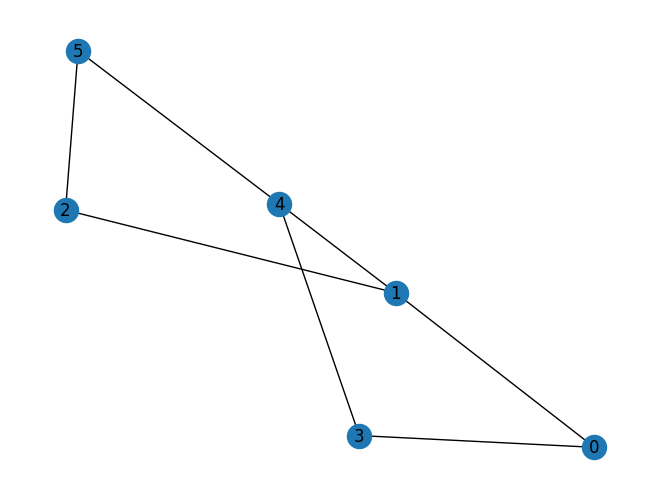

In [9]:
with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

print(f"Network nodes: {list(network_graph.nodes())}")
print(f"Network edges: {list(network_graph.edges())}")
nx.draw(network_graph, with_labels=True)

In [10]:
# Generate all multi-hop paths
ALL_PATHS = []
for pair in combinations(network_graph.nodes, 2):
    paths = nx.all_simple_paths(network_graph, source=pair[0], target=pair[1], cutoff=MAX_HOPS)
    ALL_PATHS.extend([p for p in paths if len(p) > MIN_HOPS])

print(f"Total paths ({MIN_HOPS}-{MAX_HOPS} hops): {len(ALL_PATHS)}")
print(f"Sample: {ALL_PATHS[:3]}")

Total paths (2-3 hops): 24
Sample: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3]]


## Circuit Builder (New Layout)

In [11]:
def build_513_swap_circuit(path: list, initial_state: str = '0') -> QuantumCircuit:
    """
    Build a [[5,1,3]] encode-swap-syndrome circuit using the new layout.
    
    Protocol:
        1. Encode logical qubit at source
        2. SWAP along path to sink
        3. Measure syndrome at sink using shared ancillas
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with syndrome measurement
    """
    source = path[0]
    sink = path[-1]
    
    # Get qubit assignments from new layout
    source_data = get_node_data_qubits(source)
    sink_data = get_node_data_qubits(sink)
    ancillas = get_ancilla_qubits()
    
    # Create circuit
    qc = QuantumCircuit(get_total_qubits())
    syndrome_reg = ClassicalRegister(4, name=f'syndrome_{sink}')
    qc.add_register(syndrome_reg)
    
    # ===================
    # 1. ENCODE AT SOURCE
    # ===================
    if initial_state == '1':
        qc.x(source_data[4])  # Logical qubit is index 4
    
    apply_encoding_513(qc, source_data)
    qc.barrier(label='Encode')
    
    # ===================
    # 2. SWAP ALONG PATH
    # ===================
    for i in range(len(path) - 1):
        src_node = path[i]
        dst_node = path[i + 1]
        
        src_data = get_node_data_qubits(src_node)
        dst_data = get_node_data_qubits(dst_node)
        path_qubits = get_path_qubits(src_node, dst_node)
        
        apply_swap_along_edge(qc, src_data, dst_data, path_qubits)
    
    qc.barrier(label='Swap')
    
    # ===================
    # 3. SYNDROME AT SINK (using shared ancillas)
    # ===================
    apply_syndrome_measurement_513(
        qc,
        sink_data,
        ancillas,  # Shared ancillas!
        syndrome_reg
    )
    
    return qc

## Test Circuit

In [21]:
# Build test circuit
test_path = [4, 1, 2, 5]
test_circuit = build_513_swap_circuit(test_path, initial_state='0')

print(f"Path: {test_path}")
print(f"Qubits: {test_circuit.num_qubits}")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")
print(f"\nQubit usage:")
print(f"  Ancillas: {get_ancilla_qubits()}")
print(f"  Source (node {test_path[0]}): {get_node_data_qubits(test_path[0])}")
print(f"  Intermediate (node {test_path[1]}): {get_node_data_qubits(test_path[1])}")
print(f"  Sink (node {test_path[2]}): {get_node_data_qubits(test_path[2])}")
print(f"  Path ({test_path[0]},{test_path[1]}): {get_path_qubits(test_path[0], test_path[1])}")
print(f"  Path ({test_path[1]},{test_path[2]}): {get_path_qubits(test_path[1], test_path[2])}")

Path: [4, 1, 2, 5]
Qubits: 49
Classical bits: 4
Gate counts: OrderedDict({'swap': 30, 'cz': 14, 'h': 12, 'cx': 12, 'reset': 4, 'measure': 4, 'z': 2, 'barrier': 2})

Qubit usage:
  Ancillas: [0, 1, 2, 3]
  Source (node 4): [24, 25, 26, 27, 28]
  Intermediate (node 1): [9, 10, 11, 12, 13]
  Sink (node 2): [14, 15, 16, 17, 18]
  Path (4,1): [41]
  Path (1,2): [39]


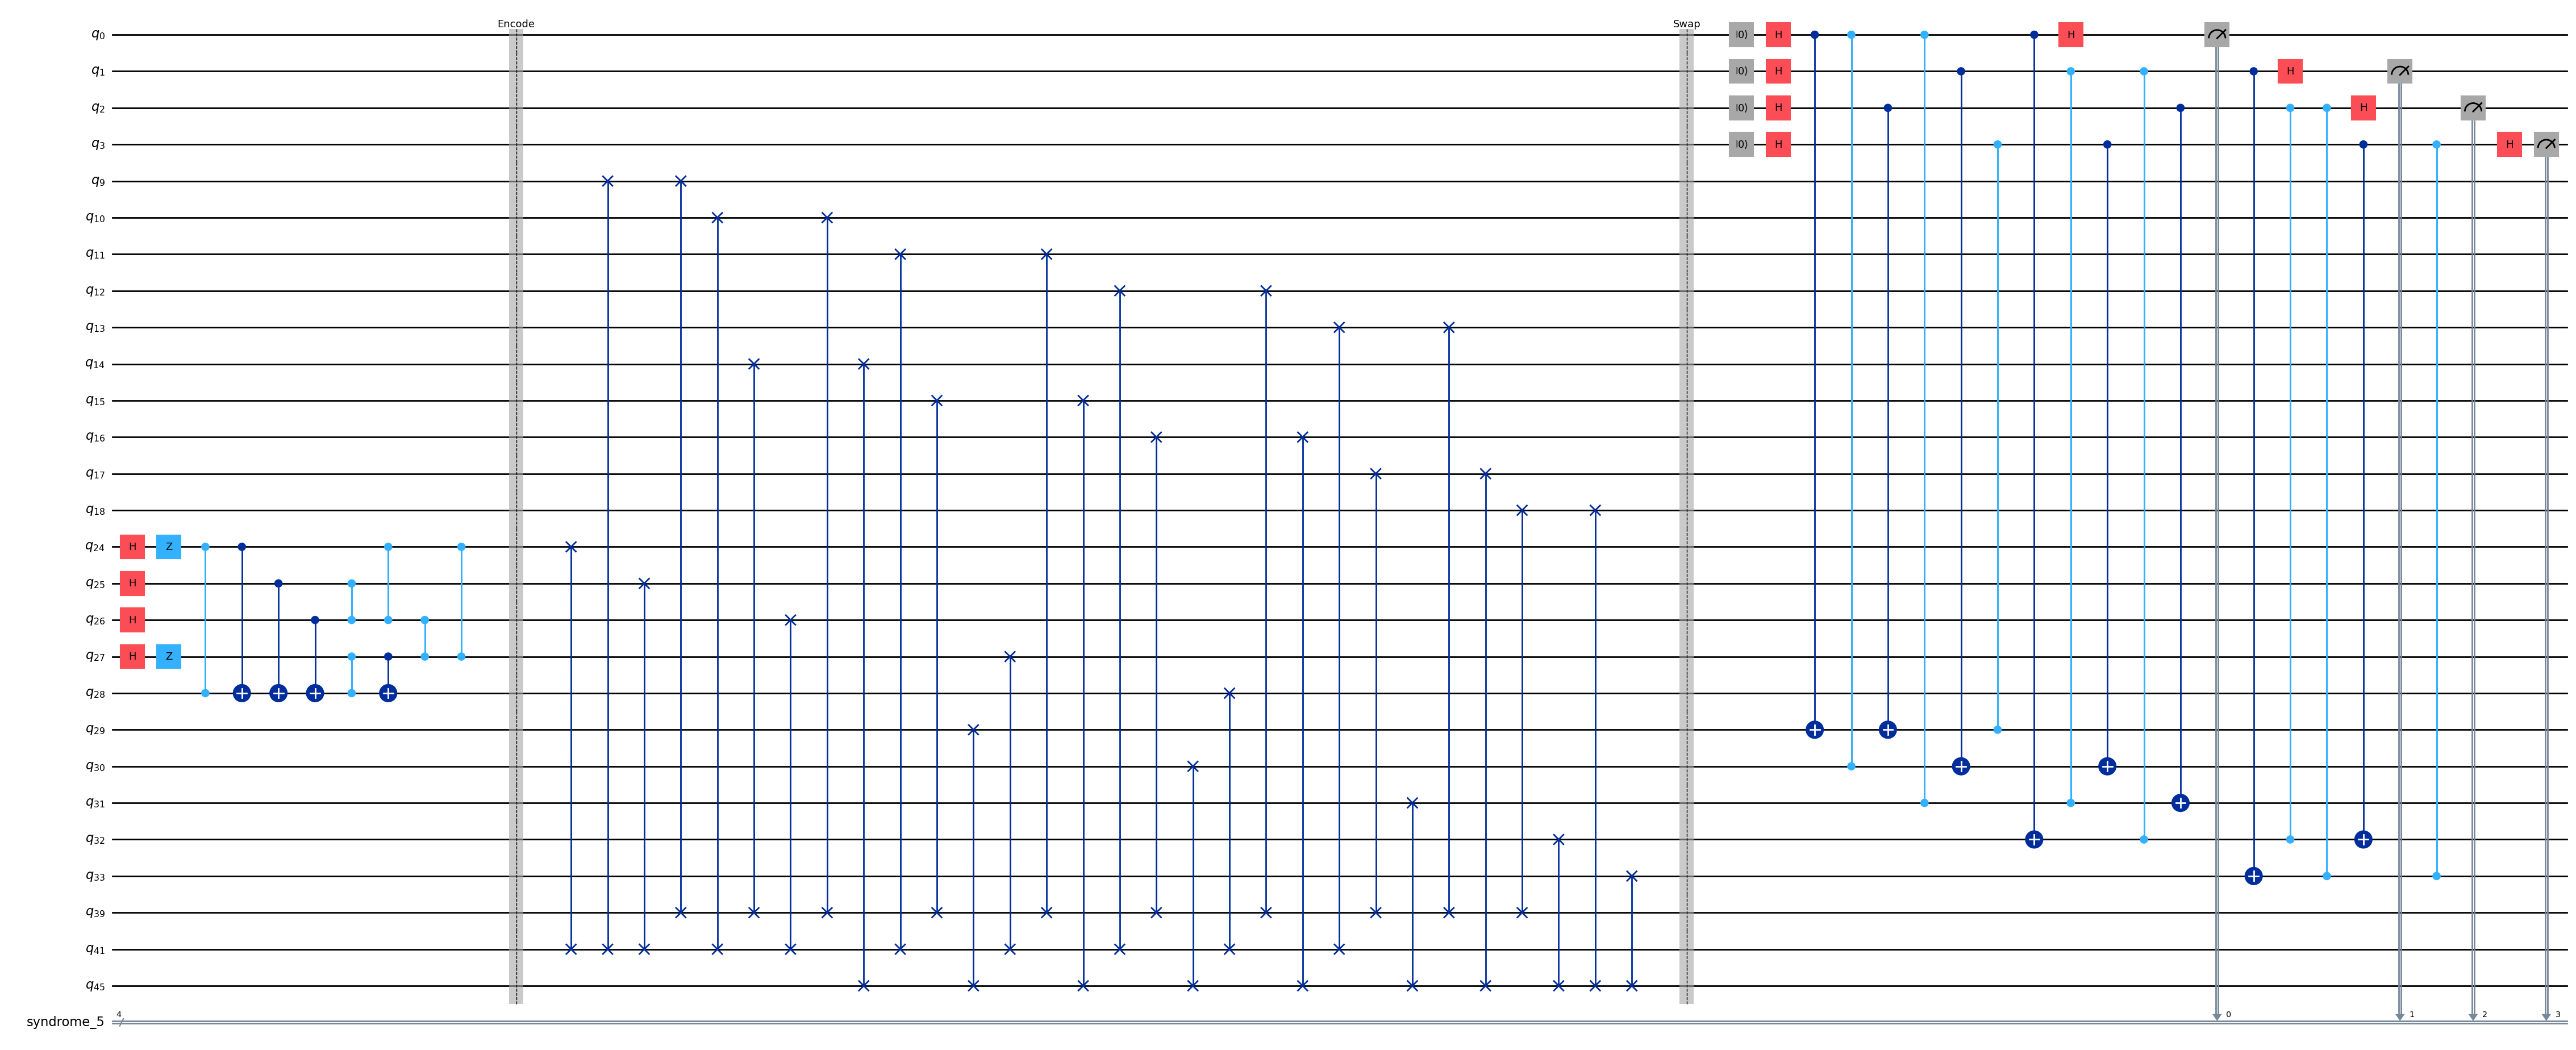

In [22]:
test_circuit.draw('mpl', fold=-1, idle_wires=False)

Noiseless syndrome counts: {'0000': 4096}


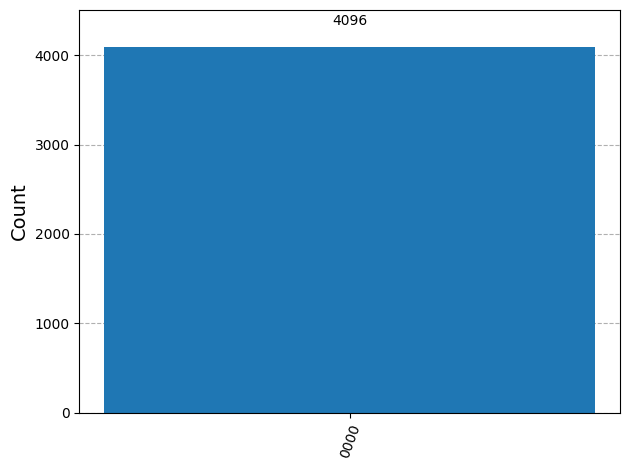

In [23]:
# Noiseless simulation
simulator = AerSimulator(method='matrix_product_state')
transpiled = transpile(test_circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

result = simulator.run(transpiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

print(f"Noiseless syndrome counts: {counts}")
plot_histogram(counts)

Noisy syndrome counts:
{'0000': 510, '0001': 15, '0010': 515, '0011': 23, '0100': 8, '0101': 483, '0110': 20, '0111': 514, '1000': 16, '1001': 492, '1010': 17, '1011': 468, '1100': 499, '1101': 18, '1110': 483, '1111': 15}


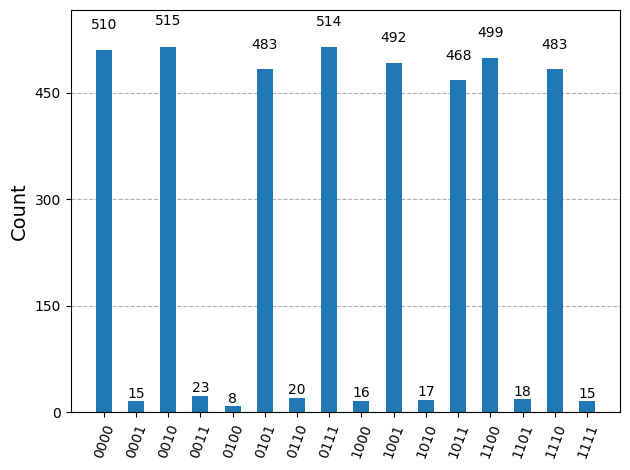

In [24]:
# Noisy simulation
noisy_simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state')

noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS).result()
noisy_counts = noisy_result.get_counts()

print("Noisy syndrome counts:")
print(dict(sorted(noisy_counts.items())))
plot_histogram(noisy_counts)

## Data Generation

In [16]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [17]:
# Setup simulator
noisy_sim = AerSimulator(noise_model=noise_model, method='matrix_product_state')

measurements = []

print("=" * 60)
print("[[5,1,3]] SYNDROME DATA GENERATION (NEW LAYOUT)")
print("=" * 60)
print(f"Total qubits: {get_total_qubits()} (vs 69 in old layout)")
print(f"Paths to process: {len(ALL_PATHS)}")
print("=" * 60)

for idx, path in enumerate(ALL_PATHS):
    print(f"\n[{idx+1}/{len(ALL_PATHS)}] Path: {path}")
    
    # Build and transpile
    circuit = build_513_swap_circuit(path, initial_state='0')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Build histogram - entries ordered by syndrome value (0000, 0001, 0010, ..., 1111)
    histogram = np.array(
        [counts.get(f"{i:04b}", 0) for i in range(16)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    measurements.append(
        TimeAwareMeasurement(path_edges, histogram, duration=0.0, latency_stats={}, code_type='513'))
    
    no_error_frac = histogram[0] / histogram.sum()
    print(f"  Edges: {path_edges}")
    print(f"  No-error fraction: {no_error_frac:.4f}")

print(f"\n{'=' * 60}")
print(f"Total measurements: {len(measurements)}")
print(f"{'=' * 60}")

[[5,1,3]] SYNDROME DATA GENERATION (NEW LAYOUT)
Total qubits: 49 (vs 69 in old layout)
Paths to process: 24

[1/24] Path: [0, 3, 4, 1]
  Edges: [(0, 3), (3, 4), (4, 1)]
  No-error fraction: 0.8931

[2/24] Path: [0, 1, 2]
  Edges: [(0, 1), (1, 2)]
  No-error fraction: 0.9268

[3/24] Path: [0, 1, 4, 3]
  Edges: [(0, 1), (1, 4), (4, 3)]
  No-error fraction: 0.9119

[4/24] Path: [0, 1, 4]
  Edges: [(0, 1), (1, 4)]
  No-error fraction: 0.9285

[5/24] Path: [0, 3, 4]
  Edges: [(0, 3), (3, 4)]
  No-error fraction: 0.9050

[6/24] Path: [0, 1, 2, 5]
  Edges: [(0, 1), (1, 2), (2, 5)]
  No-error fraction: 0.9141

[7/24] Path: [0, 1, 4, 5]
  Edges: [(0, 1), (1, 4), (4, 5)]
  No-error fraction: 0.9155

[8/24] Path: [0, 3, 4, 5]
  Edges: [(0, 3), (3, 4), (4, 5)]
  No-error fraction: 0.8838

[9/24] Path: [1, 4, 5, 2]
  Edges: [(1, 4), (4, 5), (5, 2)]
  No-error fraction: 0.9392

[10/24] Path: [1, 0, 3]
  Edges: [(1, 0), (0, 3)]
  No-error fraction: 0.9319

[11/24] Path: [1, 4, 3]
  Edges: [(1, 4), (4

## Ground Truth

In [18]:
# =============================================================================
# SYNDROME LOOKUP TABLE
# =============================================================================

STABILIZERS_513 = [
    ['X', 'Z', 'Z', 'X', 'I'],  # S1
    ['I', 'X', 'Z', 'Z', 'X'],  # S2
    ['X', 'I', 'X', 'Z', 'Z'],  # S3
    ['Z', 'X', 'I', 'X', 'Z'],  # S4
]

def compute_syndrome_513(error_type, qubit_idx):
    """Compute syndrome for a single-qubit Pauli error."""
    syndrome_bits = []
    for stabilizer in STABILIZERS_513:
        stab_op = stabilizer[qubit_idx]
        if error_type == 'X':
            anticommutes = stab_op in ['Z', 'Y']
        elif error_type == 'Z':
            anticommutes = stab_op in ['X', 'Y']
        elif error_type == 'Y':
            anticommutes = stab_op in ['X', 'Z']
        else:
            anticommutes = False
        syndrome_bits.append(1 if anticommutes else 0)
    return syndrome_bits[0] * 8 + syndrome_bits[1] * 4 + syndrome_bits[2] * 2 + syndrome_bits[3]

def build_syndrome_table():
    """Build syndrome -> error type lookup table."""
    table = {0: ('I', None)}
    for error_type in ['X', 'Y', 'Z']:
        for qubit_idx in range(5):
            syndrome = compute_syndrome_513(error_type, qubit_idx)
            if syndrome != 0:
                table[syndrome] = (error_type, qubit_idx)
    return table

def derive_pauli_rates_from_syndrome(histogram):
    """Derive Pauli rates from syndrome histogram."""
    syndrome_table = build_syndrome_table()
    total_shots = histogram.sum()
    counts = {'I': 0, 'X': 0, 'Y': 0, 'Z': 0}
    for syndrome_int in range(16):
        count = histogram[syndrome_int]
        error_type, _ = syndrome_table.get(syndrome_int, ('I', None))
        counts[error_type] += count
    return {
        'p_x': counts['X'] / total_shots,
        'p_y': counts['Y'] / total_shots,
        'p_z': counts['Z'] / total_shots,
        'p_i': counts['I'] / total_shots,
    }

syndrome_table = build_syndrome_table()
print("Syndrome Table:")
for s in range(16):
    error_type, qubit = syndrome_table.get(s, ('?', '?'))
    print(f"  {s:04b}: {error_type} on q{qubit if qubit is not None else '-'}")

Syndrome Table:
  0000: I on q-
  0001: X on q0
  0010: Z on q2
  0011: X on q4
  0100: Z on q4
  0101: Z on q1
  0110: X on q3
  0111: Y on q4
  1000: X on q1
  1001: Z on q3
  1010: Z on q0
  1011: Y on q0
  1100: X on q2
  1101: Y on q1
  1110: Y on q2
  1111: Y on q3


In [19]:
# =============================================================================
# GROUND TRUTH: SYNDROME-BASED
# =============================================================================

GROUND_TRUTH_SYNDROME = {}
GROUND_TRUTH_PAULI = {}

print("=" * 70)
print("GROUND TRUTH: SYNDROME-BASED PAULI RATE ESTIMATION")
print("=" * 70)

for edge in network_graph.edges():
    source, sink = edge
    print(f"\nEdge {edge}:")
    
    # Single-hop circuit
    circuit = build_513_swap_circuit([source, sink], initial_state='0')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    histogram = np.array([counts.get(f"{i:04b}", 0) for i in range(16)], dtype=np.float32)
    pauli_rates = derive_pauli_rates_from_syndrome(histogram)
    
    GROUND_TRUTH_SYNDROME[edge] = histogram
    GROUND_TRUTH_PAULI[edge] = [pauli_rates['p_x'], pauli_rates['p_y'], pauli_rates['p_z']]
    
    print(f"  p_X={pauli_rates['p_x']:.6f}, p_Y={pauli_rates['p_y']:.6f}, p_Z={pauli_rates['p_z']:.6f}")

print(f"\n{'=' * 70}")

GROUND TRUTH: SYNDROME-BASED PAULI RATE ESTIMATION

Edge (0, 1):
  p_X=0.010498, p_Y=0.017334, p_Z=0.024414

Edge (0, 3):
  p_X=0.015381, p_Y=0.028809, p_Z=0.031250

Edge (1, 2):
  p_X=0.008789, p_Y=0.010254, p_Z=0.013672

Edge (1, 4):
  p_X=0.010986, p_Y=0.011230, p_Z=0.016113

Edge (2, 5):
  p_X=0.006104, p_Y=0.007812, p_Z=0.010010

Edge (3, 4):
  p_X=0.009033, p_Y=0.018311, p_Z=0.024902

Edge (4, 5):
  p_X=0.130371, p_Y=0.374023, p_Z=0.369141



## Save Data

In [20]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save measurements
with open(os.path.join(OUTPUT_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(measurements, f)

# Save graph
with open(os.path.join(OUTPUT_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

with open(os.path.join(OUTPUT_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_PAULI, f)

# Save the layout itself
with open(os.path.join(OUTPUT_DIR, 'code_layout.pkl'), 'wb') as f:
    pickle.dump(CODE_LAYOUT, f)

print(f"Data saved to {OUTPUT_DIR}")
print(f"  - measurements.pkl ({len(measurements)} measurements)")
print(f"  - graph.pkl")
print(f"  - ground_truth.pkl")
print(f"  - code_layout.pkl (new layout structure)")

Data saved to ../../pickle_files/syndrome_data_513_new_layout/
  - measurements.pkl (24 measurements)
  - graph.pkl
  - ground_truth.pkl
  - code_layout.pkl (new layout structure)
